In [14]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from imblearn.over_sampling import SMOTE

In [15]:
from google.colab import files
uploaded = files.upload()

Saving dataset_Analyse_des_sentiments_clean.json to dataset_Analyse_des_sentiments_clean.json


In [16]:
df = pd.read_json('dataset_Analyse_des_sentiments_clean.json')

print(df.shape)

df.head()

(500, 12)


,Date,Auteur,Note,Version,Titre,Commentaire,Votes,satisfaction,YearMonth,word_count,clean_commentaire,clean_Titre
0,2025-09-23 13:06:00,Svent's,3,2.1.0,Bonne app mais…,"Belle interface sur iPhone, il manque juste la...",0,neutral,2025-09,34,belle interface sur iphone manque juste foncti...,bonne app mais
1,2025-09-24 06:53:00,mikael357,2,2.1.0,Pas assez intuitive,Je trouve que la nouvelle appli n’est vraiment...,0,negative,2025-09,57,trouve que nouvelle appli est vraiment pas int...,pas assez intuitive
2,2025-09-26 12:47:00,tomusspupuce,5,2.1.0,Très bon produit,Instantanément. Intelligent. Connecté.,0,positive,2025-09,3,instantanement intelligent connecte,tres bon produit
3,2025-09-27 11:24:00,Joueur Curling,5,2.1.0,Parfait,"Très utile, plus besoin de penser à ce qu’il f...",0,positive,2025-09,19,tres utile plus besoin penser faut faire surto...,parfait
4,2025-09-28 00:39:00,Amonyme,3,2.1.0,Arrêtez la mise à jour intempestive svp,L’app est simple et pratique mais il y a une s...,0,neutral,2025-09,42,app est simple pratique mais une sorte big qui...,arretez mise jour intempestive svp


# **TF-IDF**

In [17]:
df["full_text"] = (
    df["clean_Titre"].astype(str)
    + " "
    + df["clean_commentaire"].astype(str)
)
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X = vectorizer.fit_transform(
    df["full_text"]
)

y = df["satisfaction"]

# **TRAIN / TEST SPLIT**

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# **Random Forest BASELINE**

In [19]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("===== RANDOM FOREST =====")

print(classification_report(y_test, y_pred_rf))

===== RANDOM FOREST =====
              precision    recall  f1-score   support

    negative       0.69      0.68      0.68        37
     neutral       0.50      0.05      0.09        21
    positive       0.58      0.86      0.69        42

    accuracy                           0.62       100
   macro avg       0.59      0.53      0.49       100
weighted avg       0.61      0.62      0.56       100



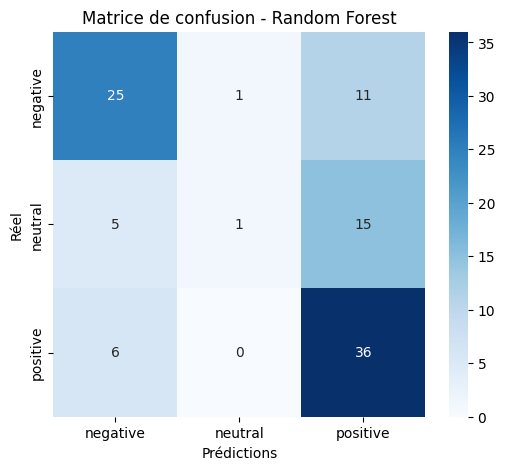

In [20]:

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=rf.classes_,
    yticklabels=rf.classes_
)

plt.xlabel('Prédictions')
plt.ylabel('Réel')

plt.title('Matrice de confusion - Random Forest')

plt.show()


# **RandomForest +class weight**


In [21]:
rf_weighted = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_weighted.fit(X_train, y_train)

y_pred_rf_weighted = rf_weighted.predict(X_test)

print("===== RANDOM FOREST + CLASS WEIGHT =====")

print(classification_report(y_test, y_pred_rf_weighted))

===== RANDOM FOREST + CLASS WEIGHT =====
              precision    recall  f1-score   support

    negative       0.67      0.65      0.66        37
     neutral       0.50      0.10      0.16        21
    positive       0.57      0.81      0.67        42

    accuracy                           0.60       100
   macro avg       0.58      0.52      0.49       100
weighted avg       0.59      0.60      0.56       100



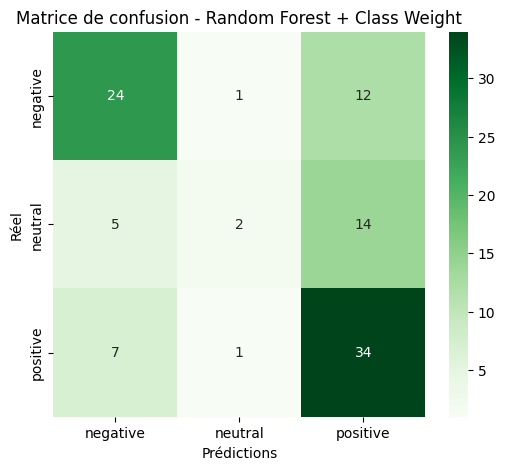

In [22]:
cm_weighted = confusion_matrix(
    y_test,
    y_pred_rf_weighted
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_weighted,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=rf_weighted.classes_,
    yticklabels=rf_weighted.classes_
)

plt.xlabel('Prédictions')
plt.ylabel('Réel')

plt.title('Matrice de confusion - Random Forest + Class Weight')

plt.show()

# **RandomForest + SMOTE**

In [23]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

rf_smote = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_smote.fit(X_train_smote, y_train_smote)

y_pred_rf_smote = rf_smote.predict(X_test)

print("===== RANDOM FOREST + SMOTE =====")

print(classification_report(y_test, y_pred_rf_smote))

===== RANDOM FOREST + SMOTE =====
              precision    recall  f1-score   support

    negative       0.72      0.70      0.71        37
     neutral       0.43      0.14      0.21        21
    positive       0.60      0.81      0.69        42

    accuracy                           0.63       100
   macro avg       0.58      0.55      0.54       100
weighted avg       0.61      0.63      0.60       100



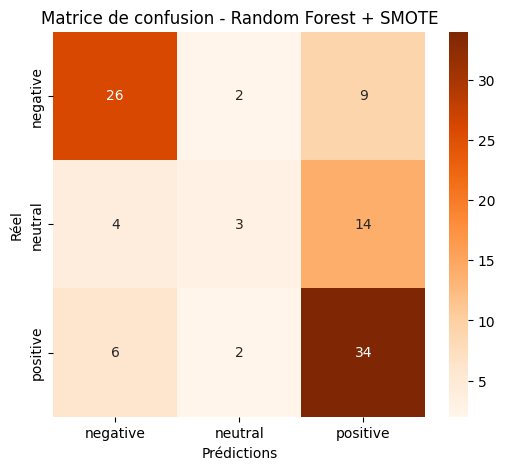

In [24]:
cm_smote = confusion_matrix(
    y_test,
    y_pred_rf_smote
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_smote,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=rf_smote.classes_,
    yticklabels=rf_smote.classes_
)

plt.xlabel('Prédictions')
plt.ylabel('Réel')

plt.title('Matrice de confusion - Random Forest + SMOTE')

plt.show()


# **TABLEAU COMPARATIF**

In [25]:
results_rf = pd.DataFrame({

    'Model': [
        'Random Forest',
        'Random Forest + Class Weight',
        'Random Forest + SMOTE'
    ],

    'Accuracy': [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_rf_weighted),
        accuracy_score(y_test, y_pred_rf_smote)
    ],

    'Precision': [
        precision_score(
            y_test,
            y_pred_rf,
            average='weighted'
        ),

        precision_score(
            y_test,
            y_pred_rf_weighted,
            average='weighted'
        ),

        precision_score(
            y_test,
            y_pred_rf_smote,
            average='weighted'
        )
    ],

    'Recall': [
        recall_score(
            y_test,
            y_pred_rf,
            average='weighted'
        ),

        recall_score(
            y_test,
            y_pred_rf_weighted,
            average='weighted'
        ),

        recall_score(
            y_test,
            y_pred_rf_smote,
            average='weighted'
        )
    ],

    'F1-score': [
        f1_score(
            y_test,
            y_pred_rf,
            average='weighted'
        ),

        f1_score(
            y_test,
            y_pred_rf_weighted,
            average='weighted'
        ),

        f1_score(
            y_test,
            y_pred_rf_smote,
            average='weighted'
        )
    ]
})

print(results_rf)


                          Model  Accuracy  Precision  Recall  F1-score
0                 Random Forest      0.62   0.605815    0.62  0.562455
1  Random Forest + Class Weight      0.60   0.589667    0.60  0.556888
2         Random Forest + SMOTE      0.63   0.607749    0.63  0.597046
